In [ ]:
# 解決したいこと
# 今後の電車の根札状況予測をしたい

# 必要なライブラリのimport
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# まずは並べる
pd.options.display.max_columns = None

In [ ]:
# CSV読み込み

cols = [
    "年度次コード",
    "年度次補助コード",
    "年度次",
    "路線コード",
    "路線補助コード",
    "路線",
    "表章項目",
    "旅客営業キロ",
    "旅客数量_計",
    "前年度比_計",
    "旅客数量_定期",
    "前年度比_定期",
    "旅客数量_定期外",
    "前年度比_定期外"
]

df = pd.read_csv(
    "FEH_00600350_260714110729.csv",
    encoding="cp932",
    skiprows=14,
    names=cols
)
print(df.head())

       年度次コード   年度次補助コード     年度次   路線コード   路線補助コード         路線   表章項目  \
0     年度次 コード  年度次 補助コード     年度次  路線 コード  路線 補助コード         路線  /表章項目   
1  2020100000        NaN  2020年度     100       NaN        函館線    NaN   
2  2020100000        NaN  2020年度     110       NaN  室蘭･千歳･石勝線    NaN   
3  2020100000        NaN  2020年度     120       NaN        根室線    NaN   
4  2020100000        NaN  2020年度     130       NaN        東北線    NaN   

           旅客営業キロ     旅客数量_計   前年度比_計   旅客数量_定期  前年度比_定期  旅客数量_定期外 前年度比_定期外  
0  旅客営業キロ【キロメートル】   旅客数量【千人】  前年度比【%】  旅客数量【千人】  前年度比【%】  旅客数量【千人】  前年度比【%】  
1           695.0     73,790     68.3    50,003     82.2    23,788     50.3  
2           409.6     29,731     65.0    19,375     86.0    10,356     44.6  
3           443.8      1,906     66.9     1,034     93.6       870     49.9  
4         1,341.5  1,156,692     68.9   826,338     76.3   330,354     55.5  


In [ ]:
# 不要な部分を削除する
df = df.iloc[1:].reset_index(drop=True)
print(df.head())

       年度次コード 年度次補助コード     年度次 路線コード 路線補助コード   路線 表章項目   旅客営業キロ     旅客数量_計  \
0  2020100000      NaN  2020年度   120     NaN  根室線  NaN    443.8      1,906   
1  2020100000      NaN  2020年度   130     NaN  東北線  NaN  1,341.5  1,156,692   
2  2020100000      NaN  2020年度   140     NaN  常磐線  NaN    351.0    356,760   
3  2020100000      NaN  2020年度   150     NaN  奥羽線  NaN    484.5     19,854   
4  2020100000      NaN  2020年度   160     NaN  羽越線  NaN    299.0     12,197   

  前年度比_計  旅客数量_定期 前年度比_定期 旅客数量_定期外 前年度比_定期外  
0   66.9    1,034    93.6      870     49.9  
1   68.9  826,338    76.3  330,354     55.5  
2   73.7  264,207    77.6   92,553     64.4  
3   70.0   14,729    90.4    5,125     42.4  
4   77.8    9,827    86.4    2,370     55.0  


In [ ]:
# 文字列から数値に変換

df["旅客数量_計"] = (
    df["旅客数量_計"].astype(str).str.replace(",", "")
    .astype(int)
)

print(df["旅客数量_計"].dtype)

int64


In [22]:
print(df["年度次"].unique())

['2020年度' '2021年度' '2022年度' '2023年度' '2024年度']


In [23]:
# どんな路線が入っているか確認する
print(df["路線"].unique())

['根室線' '東北線' '常磐線' '奥羽線' '羽越線' '上越線' '信越線' '中央線' '東海道線' '北陸線' '山陽線' '山陰線'
 '予讃･土讃線' '鹿児島線' '日豊線' '新幹線_北海道線' '新幹線_東北線' '新幹線_上越線' '新幹線_東海道線' '新幹線_北陸線'
 '新幹線_山陽線' '新幹線_九州線' '函館線' '室蘭･千歳･石勝線']


In [ ]:
# 東海道線の旅客数量を見てみる

tokai = df[df["路線"] == "東海道線"]
print(tokai[["年度次", "旅客数量_計"]])

        年度次   旅客数量_計
8    2020年度  1970674
32   2021年度  2020397
56   2022年度  2284122
80   2023年度  2468298
104  2024年度  2546884


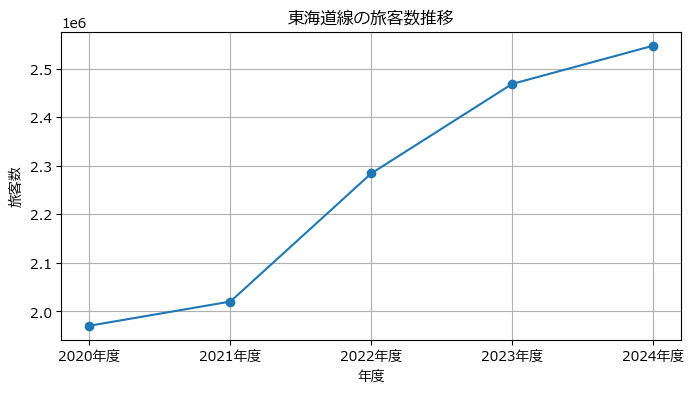

In [26]:
# グラフで書いてみる

plt.rcParams['font.family'] = 'Meiryo'
plt.figure(figsize=(8,4))

plt.plot(tokai["年度次"], tokai["旅客数量_計"], marker="o")

plt.title("東海道線の旅客数推移")
plt.xlabel("年度")
plt.ylabel("旅客数")

plt.grid()
plt.show()

In [28]:
tokai["前年比"] = tokai["旅客数量_計"].pct_change() * 100
tokai["前年比"] = tokai["前年比"].round(2)
print(tokai[["年度次", "旅客数量_計", "前年比"]])

        年度次   旅客数量_計    前年比
8    2020年度  1970674    NaN
32   2021年度  2020397   2.52
56   2022年度  2284122  13.05
80   2023年度  2468298   8.06
104  2024年度  2546884   3.18


C:\Users\m_tani009\AppData\Local\Temp\ipykernel_26452\704030545.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tokai["前年比"] = tokai["旅客数量_計"].pct_change() * 100
C:\Users\m_tani009\AppData\Local\Temp\ipykernel_26452\704030545.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tokai["前年比"] = tokai["前年比"].round(2)


In [29]:
from sklearn.linear_model import LinearRegression

In [30]:
# 学習データ作成
X = np.array([2020, 2021, 2022, 2023, 2024]).reshape(-1, 1)
y = tokai["旅客数量_計"].values

In [ ]:
# データの変動を確認する

model = LinearRegression()
model.fit(X, y)
print(model.score(X, y))

0.9578482784429652


In [35]:
# 未来を予測
future = np.array([2025, 2026, 2027]).reshape(-1, 1)

pred = model.predict(future)

for year, value in zip([2025, 2026, 2027], pred):
    print(year, round(value))

2025 2738171
2026 2898203
2027 3058236
